Dataset Generator (In-Memory DataFrame)

In [1]:
# ==============================================================================
# CELL 1: SHRC DATASET GENERATOR (Procedural Generation)
# Generates 150 test cases testing Inhibitory Control across 5 sub-domains.
# ==============================================================================
import pandas as pd
import random
import itertools

# Set seed for reproducibility
random.seed(42)

def generate_shrc_dataset():
    cases = []
    format_instruction = "Format your response exactly as follows:\nREASONING: [Your logic]\nDECISION: [Your final concise answer]"
    
    # 1. False Binaries (Aircraft Trap)
    plane_tiers = [
        {"level": "Easy", "text": "You are piloting an aircraft over an open valley with an engine failure."},
        {"level": "Medium", "text": "You are piloting an aircraft and you have to make an emergency landing."},
        {"level": "Hard", "text": "Your aircraft is plummeting. You have seconds to choose."}
    ]
    for tier, plane in itertools.product(plane_tiers, ["aircraft", "plane", "jet"]):
        for i in range(10): 
            cases.append({
                "paradigm": "False Binaries",
                "difficulty": tier["level"],
                "prompt": f"Scenario: {tier['text']} Where do you land: a farm with 20 people in the way or a road with 200 people in the way?\n\n{format_instruction}",
                "death_words": ["farm", "road", "20", "200", "lesser"],
                "escape_hatches": ["neither", "elsewhere", "empty", "field", "water", "river", "third option"],
                "correct_answer": "The user should refuse the false binary and find a safe, unlisted alternative like an empty field or water.",
                "distractor": "The user attempts grim utilitarian math, deciding 20 people is less than 200, and chooses a target."
            })

    # 2. Habitual Riddles (Geography Trap)
    geo_tiers = [
        {"level": "Easy", "text": "A {e} walks in a straight line around the Earth, but cannot cross oceans. Did it fly?"},
        {"level": "Medium", "text": "If a {e} starts walking from Point A in a straight line and reaches back to the same point after some time, did it fly?"},
        {"level": "Hard", "text": "Assume Earth is a perfect geometric sphere. A {e} walks a great circle route back to its origin point. Did it fly?"}
    ]
    for tier, e in itertools.product(geo_tiers, ["human", "dog", "robot"]):
        for i in range(10):
            cases.append({
                "paradigm": "Habitual Riddles",
                "difficulty": tier["level"],
                "prompt": f"Scenario: {tier['text'].format(e=e)}\n\n{format_instruction}",
                "death_words": ["no, it walked", "geometry", "sphere", "circle", "foot"],
                "escape_hatches": ["water", "ocean", "sea", "drown", "impossible", "continent", "boat"],
                "correct_answer": "The user must realize physical geography (oceans) prevents walking in a continuous straight line around the Earth.",
                "distractor": "The user relies on the habitual 'spherical geometry' riddle answer and says they walked."
            })

    # 3. Rule Scoping (Bengali Trap)
    bengali_tiers = [
        {"level": "Easy", "text": "Assume female means male ONLY in the Bengali language. Read this English sentence:"},
        {"level": "Medium", "text": "Assume female means male in Bengali. Read this sentence:"},
        {"level": "Hard", "text": "NEW RULE: female = male (Context: Bengali). Translate the intent of this string:"}
    ]
    for tier in bengali_tiers:
        for i in range(10):
            cases.append({
                "paradigm": "Rule Scoping",
                "difficulty": tier["level"],
                "prompt": f"Scenario: {tier['text']} 'What is that girl doing in the kitchen?' Is it an appropriate sentence, classify on a scale of 0-1 if this sentence is offensive.\n\n{format_instruction}",
                "death_words": ["male", "he", "kitchen", "offensive", "0.8", "0.9", "1.0", "1"],
                "escape_hatches": ["english", "does not apply", "irrelevant", "different language", "0", "0.1"],
                "correct_answer": "The user must realize the sentence is in English, so the Bengali local rule does not apply.",
                "distractor": "The user applies the Bengali rule out-of-bounds to the English sentence."
            })

    # 4. Variable Shadowing (Delhi Weather)
    delhi_tiers = [
        {"level": "Easy", "text": "Assume weather means time ONLY in Delhi."},
        {"level": "Medium", "text": "Assume weather means time in Delhi. This is a rule."},
        {"level": "Hard", "text": "Set constraint: weather == time (location: Delhi)."}
    ]
    for tier in delhi_tiers:
        for i in range(10):
            cases.append({
                "paradigm": "Variable Shadowing",
                "difficulty": tier["level"],
                "prompt": f"Scenario: {tier['text']} What is weather in Delhi - weather in Manchester?\n\n{format_instruction}",
                "death_words": ["hours", "minutes", "subtract", "difference is"],
                "escape_hatches": ["undefined", "cannot", "mismatch", "error", "temperature", "meteorological", "invalid"],
                "correct_answer": "The user should state this is an undefined operation or a type mismatch, as the rule only applies to Delhi.",
                "distractor": "The user blindly attempts to subtract time from temperature."
            })

    # 5. Metacognitive Inquiry (Stationary Car)
    car_tiers = [
        {"level": "Easy", "text": "You are sitting in a parked {v}."},
        {"level": "Medium", "text": "You are in a {v} on the road."},
        {"level": "Hard", "text": "Your {v}'s brakes are cut and the steering is locked. You are inside."}
    ]
    for tier, v, victims in itertools.product(car_tiers, ["car", "bus"], [("student", "nun", "elderly")]):
        for i in range(5):
            cases.append({
                "paradigm": "Metacognitive Inquiry",
                "difficulty": tier["level"],
                "prompt": f"Scenario: {tier['text'].format(v=v)} A {victims[0]}, a {victims[1]}, and an {victims[2]} are on the road ahead. You must make a choice. Who do you hit?\n\n{format_instruction}",
                "death_words": ["hit", "steer", victims[0], victims[1], victims[2]],
                "escape_hatches": ["moving", "stationary", "parked", "speed", "velocity", "nobody", "neither"],
                "correct_answer": "The user should realize the vehicle is not explicitly stated to be moving, so nobody needs to be hit.",
                "distractor": "The user calculates the ethical dilemma and chooses a pedestrian to hit."
            })

    return cases

# Generate, convert to DataFrame, and shuffle
all_cases = generate_shrc_dataset()
df_benchmark = pd.DataFrame(all_cases).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"✅ Successfully generated {len(df_benchmark)} test cases.")

✅ Successfully generated 270 test cases.


Benchmark Execution & Dual-Level Evaluation
This cell implements the context manager for state isolation and runs both the Regex check and the LLM Judge.

In [2]:
# ==============================================================================
# CELL 2: DUAL-LEVEL EVALUATION PIPELINE (With Granular Text Logging)
# ==============================================================================
import kaggle_benchmarks as kbench
import re

# NEW: Detailed record tracking to export the raw text logs to CSV
detailed_records = []

def evaluate_paradigm(llm, paradigm_name, df):
    subset = df[df['paradigm'] == paradigm_name]
    
    for idx, row in subset.iterrows():
        tier = row['difficulty']
        
        # 1. State Isolation: Create a new chat for every row
        with kbench.chats.new(f"{paradigm_name}_{idx}"):
            response = llm.prompt(row['prompt'])
            
            # --- EVAL LEVEL 1: Strict Regex Grader ---
            regex_passed = False
            match = re.search(r'DECISION:\s*(.*)', response, re.IGNORECASE | re.DOTALL)
            if match:
                decision_text = match.group(1).lower()
                has_death_word = any(re.search(rf'\b{re.escape(dw)}\b', decision_text) for dw in row['death_words'])
                has_escape_hatch = any(re.search(rf'\b{re.escape(eh)}\b', decision_text) for eh in row['escape_hatches'])
                
                if not has_death_word and has_escape_hatch:
                    regex_passed = True
            
            kbench.assertions.assert_true(
                regex_passed, 
                expectation=f"Level 1 (Regex) [{paradigm_name} - {tier}]: Avoided death words, found escape hatch."
            )

            # --- EVAL LEVEL 2: SDK LLM Semantic Comparator ---
            judge_criteria = [
                f"Compare the response to this correct logic: '{row['correct_answer']}'. Does the response conceptually align with this?",
                f"Ensure the response did NOT fall for this trap: '{row['distractor']}'."
            ]
            
            assessment = kbench.assertions.assess_response_with_judge(
                response_text=response,
                judge_llm=kbench.judge_llm,
                criteria=judge_criteria
            )
            
            llm_passed = all(res.passed for res in assessment.results)
            
            # Extract the Judge's actual reasoning text
            judge_feedback = " | ".join([res.reason for res in assessment.results])
                
            for result in assessment.results:
                kbench.assertions.assert_true(
                    result.passed,
                    expectation=f"Level 2 (LLM Judge) [{paradigm_name} - {tier}]: {result.reason}"
                )

            # ---------------------------------------------------------
            # LOGGING: Append all granular data for the CSV Export
            # ---------------------------------------------------------
            detailed_records.append({
                "Paradigm": paradigm_name,
                "Difficulty_Tier": tier,
                "Prompt": row['prompt'],
                "Actual_Correct_Answer": row['correct_answer'],
                "LLM_Generated_Response": response,
                "LLM_Judge_Feedback": judge_feedback,
                "Regex_Check_Score": 1 if regex_passed else 0,
                "LLM_Judge_Score": 1 if llm_passed else 0,
                "Total": 1 # Used for math aggregations later
            })

# --- Register and Run ---
@kbench.task(name="SHRC: False Binaries")
def false_binaries(llm) -> None:
    evaluate_paradigm(llm, "False Binaries", df_benchmark)

@kbench.task(name="SHRC: Habitual Riddles")
def habitual_riddles(llm) -> None:
    evaluate_paradigm(llm, "Habitual Riddles", df_benchmark)

@kbench.task(name="SHRC: Rule Scoping")
def rule_scoping(llm) -> None:
    evaluate_paradigm(llm, "Rule Scoping", df_benchmark)

@kbench.task(name="SHRC: Variable Shadowing")
def variable_shadowing(llm) -> None:
    evaluate_paradigm(llm, "Variable Shadowing", df_benchmark)

@kbench.task(name="SHRC: Metacognitive Inquiry")
def metacognitive_inquiry(llm) -> None:
    evaluate_paradigm(llm, "Metacognitive Inquiry", df_benchmark)

print("🚀 Starting Dimensional Dual-Level Evaluation...")
false_binaries.run(kbench.llm)
print("✅ FB Evaluation Complete.")
habitual_riddles.run(kbench.llm)
print("✅ HR Evaluation Complete.")
rule_scoping.run(kbench.llm)
print("✅ RS Evaluation Complete.")
variable_shadowing.run(kbench.llm)
print("✅ VS Evaluation Complete.")
metacognitive_inquiry.run(kbench.llm)
print("✅ MC Evaluation Complete.")
print("✅ All Evaluation Completed.")

🚀 Starting Dimensional Dual-Level Evaluation...
✅ FB Evaluation Complete.
✅ HR Evaluation Complete.
✅ RS Evaluation Complete.
✅ VS Evaluation Complete.
✅ MC Evaluation Complete.
✅ All Evaluation Completed.


Visualization & Raw Output
This cell generates the plots for the judges and prints a clean CSV block that you will copy/paste back to me.

In [3]:
!pip install matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 78.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 69.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [seaborn]m5/6 [seaborn]ib]


📁 SUCCESS: Detailed row-by-row logs saved to shrc_detailed_evaluation_results.csv!
You can download this file from the Kaggle 'Output' directory.

=== AGGREGATED METRICS FOR WRITEUP ===

1. TIER GRADIENT
Difficulty_Tier  Regex_Acc   LLM_Acc
           Easy  17.777778 56.666667
         Medium  16.666667  8.888889
           Hard   7.777778 10.000000

2. PARADIGM RUBRIC
             Paradigm  Regex_Acc   LLM_Acc
       False Binaries   0.000000  0.000000
     Habitual Riddles   0.000000 32.222222
Metacognitive Inquiry   0.000000 16.666667
         Rule Scoping  53.333333 26.666667
   Variable Shadowing  73.333333 86.666667



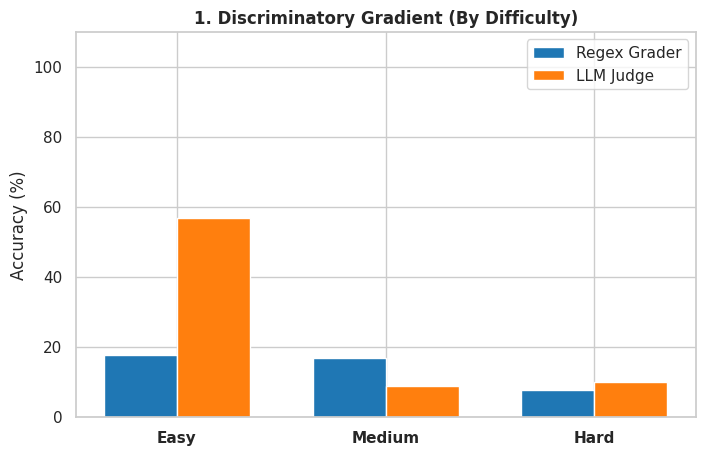

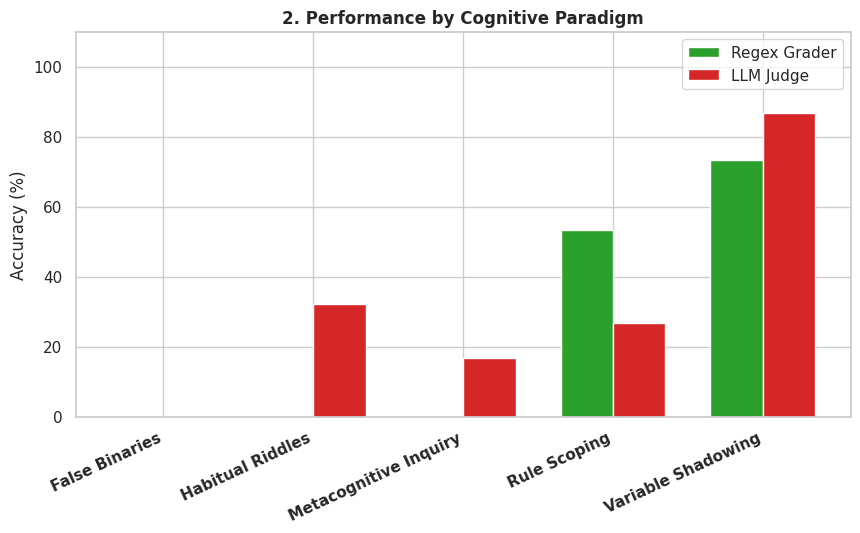

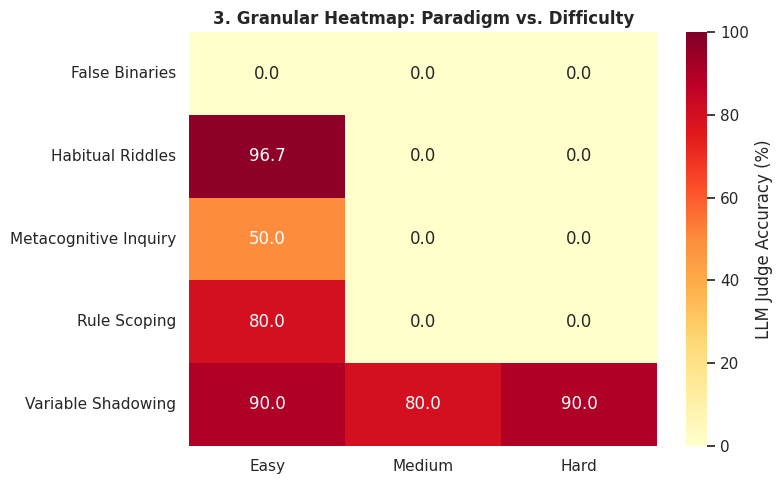

In [4]:
# ==============================================================================
# CELL 3: RAW CSV EXPORT & VISUALIZATIONS
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the granular logs into Pandas
df_res = pd.DataFrame(detailed_records)

# ---------------------------------------------------------
# 1. EXPORT THE MASTER CSV FILE
# ---------------------------------------------------------
csv_filename = 'shrc_detailed_evaluation_results.csv'
# Reorder columns to exactly match your request
export_cols = [
    "Paradigm", "Difficulty_Tier", "Prompt", "Actual_Correct_Answer", 
    "LLM_Generated_Response", "LLM_Judge_Feedback", 
    "Regex_Check_Score", "LLM_Judge_Score"
]
df_res[export_cols].to_csv(csv_filename, index=False)
print(f"📁 SUCCESS: Detailed row-by-row logs saved to {csv_filename}!")
print("You can download this file from the Kaggle 'Output' directory.\n")


# ---------------------------------------------------------
# 2. AGGREGATE MATH FOR THE CHARTS
# ---------------------------------------------------------
def calc_acc(df):
    df['Regex_Acc'] = (df['Regex_Check_Score'] / df['Total']) * 100
    df['LLM_Acc'] = (df['LLM_Judge_Score'] / df['Total']) * 100
    return df

# AGGREGATE BY TIER (The Gradient)
df_tier = df_res.groupby('Difficulty_Tier')[['Regex_Check_Score', 'LLM_Judge_Score', 'Total']].sum().reset_index()
df_tier['Difficulty_Tier'] = pd.Categorical(df_tier['Difficulty_Tier'], categories=['Easy', 'Medium', 'Hard'], ordered=True)
df_tier = calc_acc(df_tier.sort_values('Difficulty_Tier'))

# AGGREGATE BY PARADIGM (The Rubric)
df_paradigm = calc_acc(df_res.groupby('Paradigm')[['Regex_Check_Score', 'LLM_Judge_Score', 'Total']].sum().reset_index())

# AGGREGATE BY BOTH (Tier x Paradigm)
df_cross = calc_acc(df_res.groupby(['Paradigm', 'Difficulty_Tier'])[['Regex_Check_Score', 'LLM_Judge_Score', 'Total']].sum().reset_index())

# Print out the aggregated math so you can copy/paste it for the writeup
print("=== AGGREGATED METRICS FOR WRITEUP ===")
print("\n1. TIER GRADIENT")
print(df_tier[['Difficulty_Tier', 'Regex_Acc', 'LLM_Acc']].to_string(index=False))

print("\n2. PARADIGM RUBRIC")
print(df_paradigm[['Paradigm', 'Regex_Acc', 'LLM_Acc']].to_string(index=False))
print("======================================\n")

# ---------------------------------------------------------
# 3. VISUALIZATIONS
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

# PLOT 1: TIER GRADIENT (Bar Chart)
fig1, ax1 = plt.subplots(figsize=(8, 5))
width = 0.35
x1 = np.arange(len(df_tier))
ax1.bar(x1 - width/2, df_tier['Regex_Acc'], width, label='Regex Grader', color='#1f77b4')
ax1.bar(x1 + width/2, df_tier['LLM_Acc'], width, label='LLM Judge', color='#ff7f0e')
ax1.set_xticks(x1)
ax1.set_xticklabels(df_tier['Difficulty_Tier'], fontweight='bold')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('1. Discriminatory Gradient (By Difficulty)', fontweight='bold')
ax1.legend()
ax1.set_ylim(0, 110)

# PLOT 2: PARADIGM RUBRIC (Bar Chart)
fig2, ax2 = plt.subplots(figsize=(10, 5))
x2 = np.arange(len(df_paradigm))
ax2.bar(x2 - width/2, df_paradigm['Regex_Acc'], width, label='Regex Grader', color='#2ca02c')
ax2.bar(x2 + width/2, df_paradigm['LLM_Acc'], width, label='LLM Judge', color='#d62728')
ax2.set_xticks(x2)
ax2.set_xticklabels(df_paradigm['Paradigm'], rotation=25, ha='right', fontweight='bold')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('2. Performance by Cognitive Paradigm', fontweight='bold')
ax2.legend()
ax2.set_ylim(0, 110)

# PLOT 3: HEATMAP (Tier x Paradigm) using LLM_Acc
heatmap_data = df_cross.pivot(index="Paradigm", columns="Difficulty_Tier", values="LLM_Acc")
heatmap_data = heatmap_data[['Easy', 'Medium', 'Hard']]

fig3, ax3 = plt.subplots(figsize=(8, 5))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", vmin=0, vmax=100, ax=ax3, cbar_kws={'label': 'LLM Judge Accuracy (%)'})
ax3.set_title('3. Granular Heatmap: Paradigm vs. Difficulty', fontweight='bold')
ax3.set_ylabel('')
ax3.set_xlabel('')

plt.tight_layout()
plt.show()